In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style='whitegrid')

In [42]:
file_path = "marketing_data.csv"
df = pd.read_csv(file_path)

# df = pd.read_csv('marketing_data.csv')
print(df.head())

      ID  Year_Birth   Education Marital_Status       Income  Kidhome  \
0   1826        1970  Graduation       Divorced  $84,835.00         0   
1      1        1961  Graduation         Single  $57,091.00         0   
2  10476        1958  Graduation        Married  $67,267.00         0   
3   1386        1967  Graduation       Together  $32,474.00         1   
4   5371        1989  Graduation         Single  $21,474.00         1   

   Teenhome Dt_Customer  Recency  MntWines  ...  NumStorePurchases  \
0         0     6/16/14        0       189  ...                  6   
1         0     6/15/14        0       464  ...                  7   
2         1     5/13/14        0       134  ...                  5   
3         1     5/11/14        0        10  ...                  2   
4         0      4/8/14        0         6  ...                  2   

   NumWebVisitsMonth  AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  \
0                  1             0             0            

In [43]:
df.info()

print("\nMissing values per column:")
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4   Income               2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

In [44]:
# 3.1 Convert Dt_Customer to datetime
if "Dt_Customer" in df.columns:
    df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")

# 3.2 Clean Education categories
if "Education" in df.columns:
    df["Education"] = df["Education"].replace({
        "2n Cycle": "Graduate",
        "Basic": "Undergraduate",
        "Graduation": "Graduate",
        "PhD": "PostGraduate"
    })

# 3.3 Clean Marital_Status categories
if "Marital_Status" in df.columns:
    df["Marital_Status"] = df["Marital_Status"].replace({
        "Together": "Married",
        "YOLO": "Single",
        "Alone": "Single",
        "Absurd": "Single",
        "Widow": "Single"
    })

# 3.4 Impute missing Income based on Education & Marital_Status group means
if "Income" in df.columns:
    df["Income"] = (
        df["Income"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace(" ", "", regex=False)
        .replace(["", "None", "nan", "N/A"], np.nan)
    ).astype(float)
    print("Missing Income before:", df["Income"].isna().sum())
    df["Income"] = df.groupby(["Education", "Marital_Status"])["Income"].transform(
        lambda x: x.fillna(x.mean())
    )
    # Fallback: global median
    df["Income"] = df["Income"].fillna(df["Income"].median())
    print("Missing Income after:", df["Income"].isna().sum())

df.head()


Missing Income before: 24
Missing Income after: 0


C:\Users\malha\AppData\Local\Temp\ipykernel_21408\153781895.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduate,Divorced,84835.0,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduate,Single,57091.0,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduate,Married,67267.0,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduate,Married,32474.0,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduate,Single,21474.0,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [45]:
# 4.1 TotalChildren
if {"Kidhome", "Teenhome"}.issubset(df.columns):
    df["TotalChildren"] = df["Kidhome"] + df["Teenhome"]
else:
    df["TotalChildren"] = np.nan

# 4.2 Age calculation using Dt_Customer year as reference (fallback 2015)
if "Year_Birth" in df.columns:
    if "Dt_Customer" in df.columns and df["Dt_Customer"].notna().any():
        ref_year = df["Dt_Customer"].dt.year.max()
    else:
        ref_year = 2015
    df["Age"] = ref_year - df["Year_Birth"]
else:
    df["Age"] = np.nan

# 4.3 TotalSpending from all Mnt* columns
mnt_cols = [c for c in df.columns if c.startswith("Mnt")]  # e.g., MntWines, MntFruits, etc.
if mnt_cols:
    df["TotalSpending"] = df[mnt_cols].sum(axis=1)
else:
    df["TotalSpending"] = np.nan

# 4.4 TotalPurchases across channels
purchase_cols = [c for c in ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"] if c in df.columns]
if purchase_cols:
    df["TotalPurchases"] = df[purchase_cols].sum(axis=1)
else:
    df["TotalPurchases"] = np.nan

df[["Income", "Age", "TotalChildren", "TotalSpending", "TotalPurchases"]].head()


,Income,Age,TotalChildren,TotalSpending,TotalPurchases
0,84835.0,44,0,1190,14
1,57091.0,53,0,577,17
2,67267.0,56,1,251,10
3,32474.0,47,2,11,3
4,21474.0,25,1,91,6


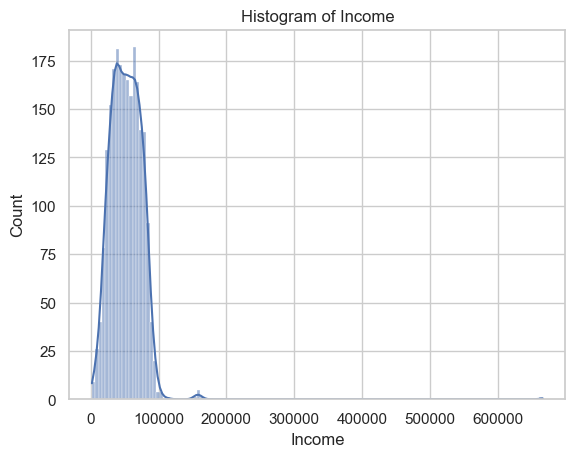

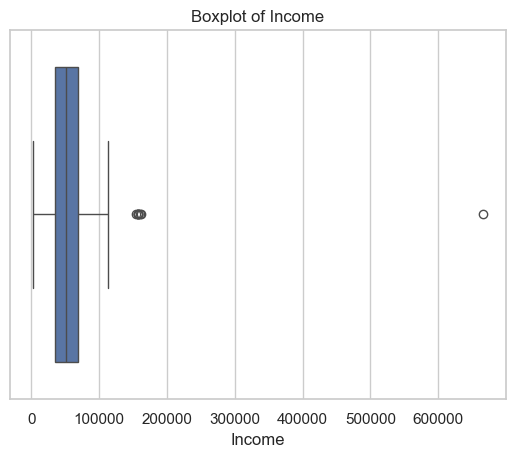

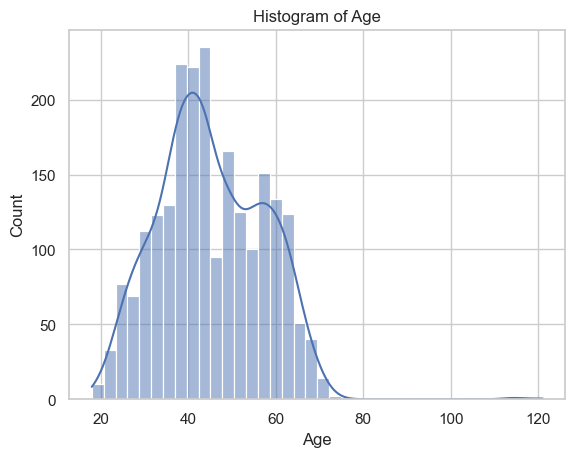

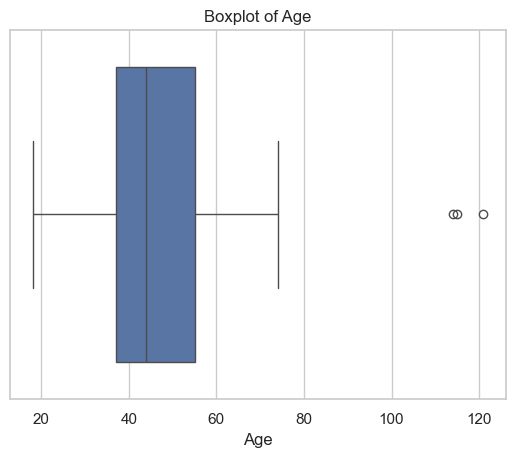

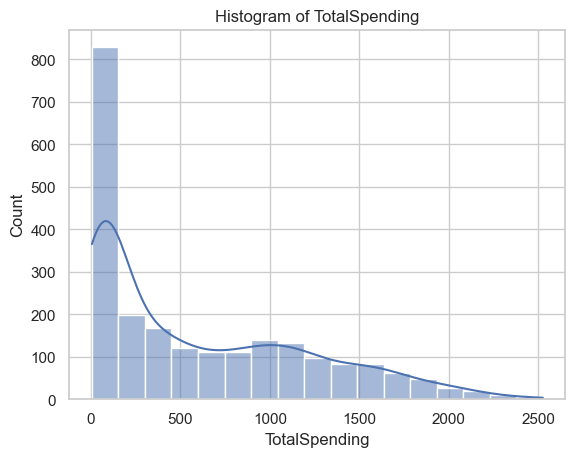

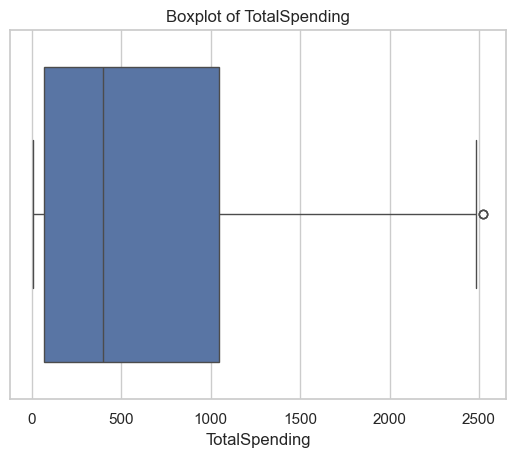

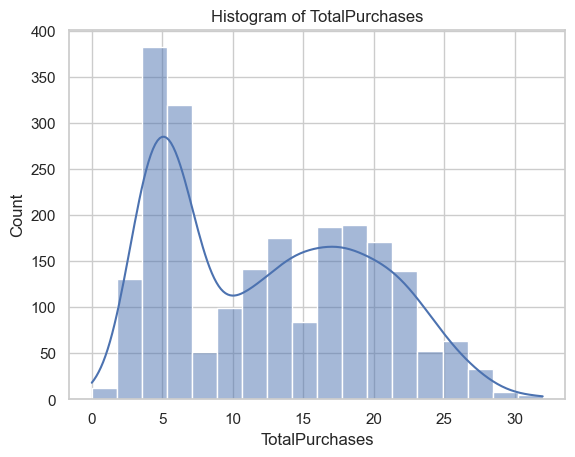

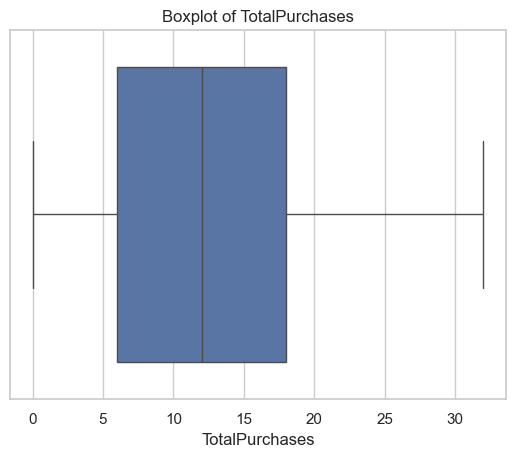

,count,mean,std,min,25%,50%,75%,max
Income,2240.0,52255.292210,25038.655094,1730.0,35538.75,51630.358824,68289.75,666666.0
Age,2240.0,45.194196,11.984069,18.0,37.00,44.000000,55.00,121.0
TotalSpending,2240.0,605.798214,602.249288,5.0,68.75,396.000000,1045.50,2525.0
TotalPurchases,2240.0,12.537054,7.205741,0.0,6.00,12.000000,18.00,32.0


In [46]:
numeric_focus = ["Income", "Age", "TotalSpending", "TotalPurchases"]
numeric_focus = [c for c in numeric_focus if c in df.columns]

for col in numeric_focus:
    plt.figure()
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

df[numeric_focus].describe().T


In [47]:
def cap_outliers(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return np.clip(series, lower, upper)

for col in ["Income", "TotalSpending", "TotalPurchases"]:
    if col in df.columns:
        print(f"Capping outliers for {col}")
        df[col] = cap_outliers(df[col])

df[[c for c in ["Income", "TotalSpending", "TotalPurchases"] if c in df.columns]].describe().T


Capping outliers for Income
Capping outliers for TotalSpending
Capping outliers for TotalPurchases


,count,mean,std,min,25%,50%,75%,max
Income,2240.0,51883.191317,20937.248906,1730.0,35538.75,51630.358824,68289.75,117416.250
TotalSpending,2240.0,605.779408,602.189559,5.0,68.75,396.000000,1045.50,2510.625
TotalPurchases,2240.0,12.537054,7.205741,0.0,6.00,12.000000,18.00,32.000


In [48]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical columns
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

ordinal_features = []
nominal_features = []

if "Education" in cat_cols:
    ordinal_features.append("Education")
if "Marital_Status" in cat_cols:
    nominal_features.append("Marital_Status")

for c in cat_cols:
    if c not in ordinal_features and c not in nominal_features:
        nominal_features.append(c)

expected_eds = ["Undergraduate", "Graduate", "PostGraduate"]

if "Education" in df.columns:
    uniq = df["Education"].dropna().astype(str).unique().tolist()
    unknowns = [u for u in uniq if u not in expected_eds]
    if unknowns:
        print("Unknown Education categories detected:", unknowns)
        mapping = {}
        for u in unknowns:
            lu = u.lower()
            if "master" in lu or "ms" in lu:
                mapping[u] = "PostGraduate"
            elif "phd" in lu or "doctor" in lu:
                mapping[u] = "PostGraduate"
            elif "grad" in lu:
                mapping[u] = "Graduate"
            elif "basic" in lu or "undergrad" in lu:
                mapping[u] = "Undergraduate"
            else:
                mapping[u] = "Graduate"
        df["Education"] = df["Education"].replace(mapping)

education_order = [expected_eds]  # one list per ordinal feature

transformers = []
if ordinal_features:
    transformers.append((
        "edu_ord",
        OrdinalEncoder(categories=education_order, handle_unknown="use_encoded_value", unknown_value=-1),
        ["Education"]
    ))

if nominal_features:
    transformers.append((
        "nom_ohe",
        OneHotEncoder(drop="first", handle_unknown="ignore"),
        nominal_features
    ))

preprocessor = ColumnTransformer(transformers=transformers, remainder="passthrough")
encoded_array = preprocessor.fit_transform(df)
print("Encoded shape:", encoded_array.shape)


Unknown Education categories detected: ['Master']
Encoded shape: (2240, 39)


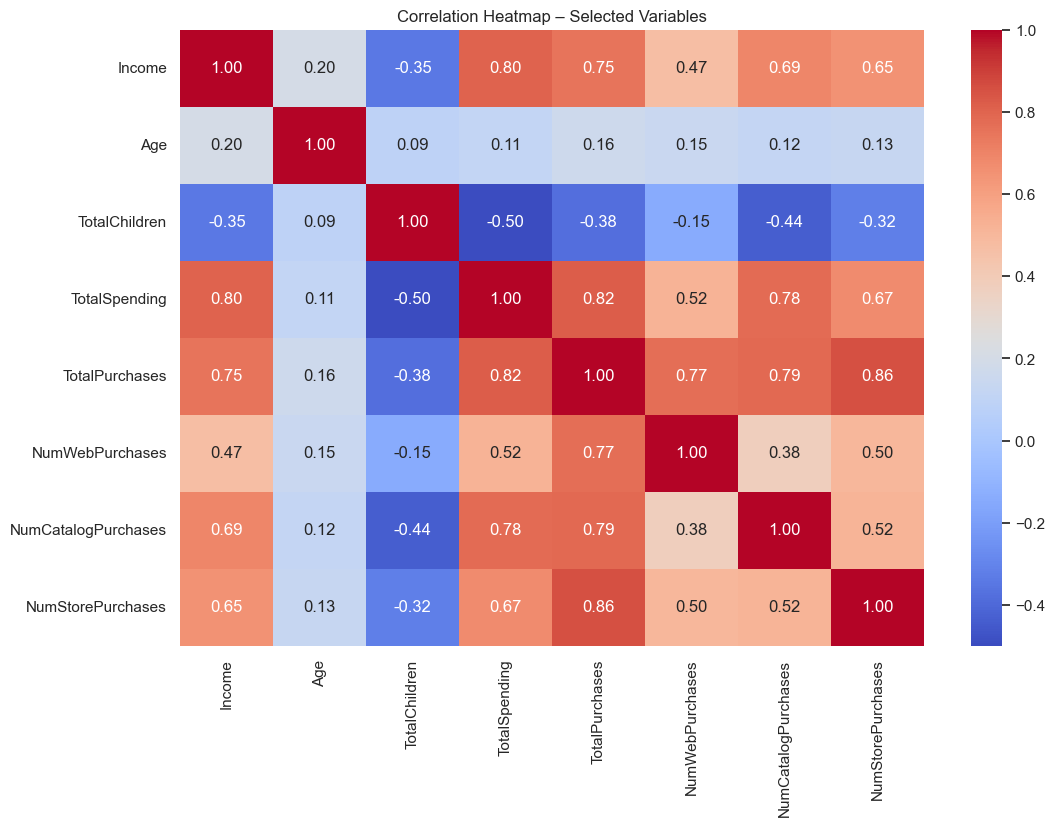

In [49]:
corr_cols = ["Income", "Age", "TotalChildren", "TotalSpending", "TotalPurchases",
             "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
corr_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(12, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap – Selected Variables")
plt.show()


H1 – Older vs Young: NumStorePurchases
t-statistic: 5.724431686389027 p-value: 1.3688937285719277e-08


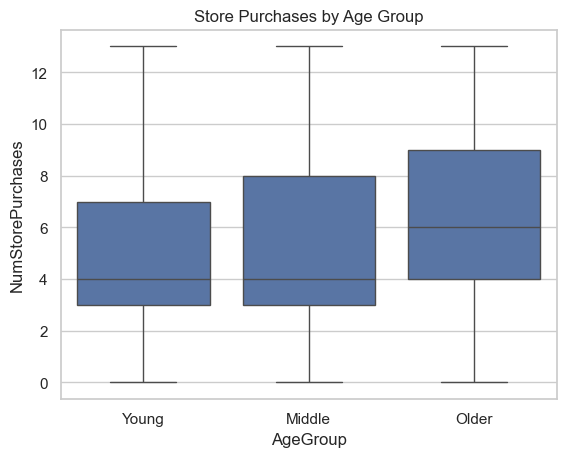

In [50]:
# Create AgeGroup categories
if "Age" in df.columns:
    df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 35, 50, 120], labels=["Young", "Middle", "Older"])
else:
    df["AgeGroup"] = np.nan

if {"AgeGroup", "NumStorePurchases"}.issubset(df.columns):
    older_store = df.loc[df["AgeGroup"] == "Older", "NumStorePurchases"].dropna()
    young_store = df.loc[df["AgeGroup"] == "Young", "NumStorePurchases"].dropna()

    t_stat, p_val = stats.ttest_ind(older_store, young_store, equal_var=False)
    print("H1 – Older vs Young: NumStorePurchases")
    print("t-statistic:", t_stat, "p-value:", p_val)

    plt.figure()
    sns.boxplot(x="AgeGroup", y="NumStorePurchases", data=df)
    plt.title("Store Purchases by Age Group")
    plt.show()
else:
    print("Required columns for H1 not present.")


H2 – Web Purchases: Parents vs Non-parents
t-statistic: -3.541893836382714 p-value: 0.0004108102700005601


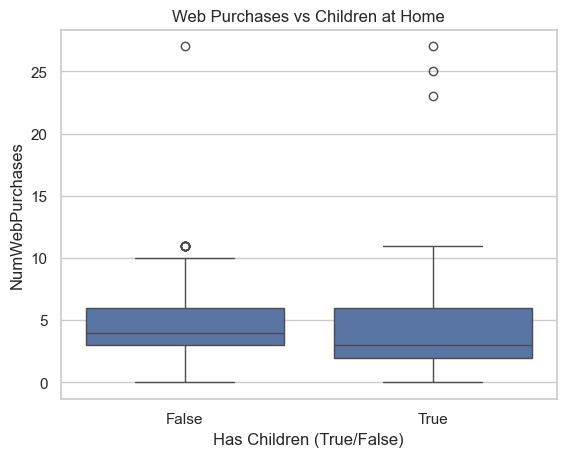

In [51]:
if {"TotalChildren", "NumWebPurchases"}.issubset(df.columns):
    parents = df[df["TotalChildren"] > 0]["NumWebPurchases"].dropna()
    non_parents = df[df["TotalChildren"] == 0]["NumWebPurchases"].dropna()

    t_stat, p_val = stats.ttest_ind(parents, non_parents, equal_var=False)
    print("H2 – Web Purchases: Parents vs Non-parents")
    print("t-statistic:", t_stat, "p-value:", p_val)

    plt.figure()
    sns.boxplot(x=(df["TotalChildren"] > 0), y="NumWebPurchases", data=df)
    plt.xlabel("Has Children (True/False)")
    plt.title("Web Purchases vs Children at Home")
    plt.show()
else:
    print("Required columns for H2 not present.")


H3 – Correlation between store and other channels: 0.615359297863022


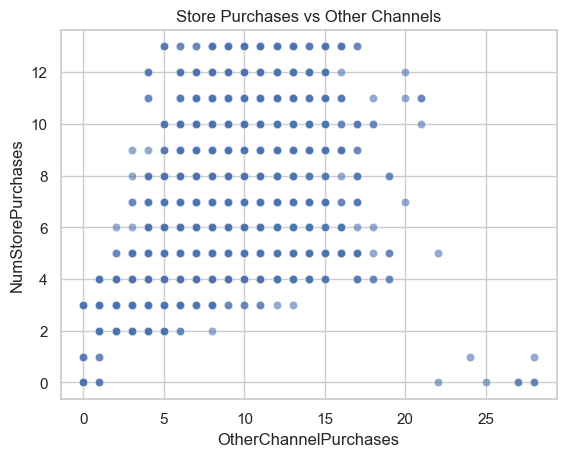

In [52]:
if {"NumStorePurchases", "NumWebPurchases", "NumCatalogPurchases"}.issubset(df.columns):
    df["OtherChannelPurchases"] = df["NumWebPurchases"] + df["NumCatalogPurchases"]
    corr_store_other = df["NumStorePurchases"].corr(df["OtherChannelPurchases"])
    print("H3 – Correlation between store and other channels:", corr_store_other)

    plt.figure()
    sns.scatterplot(x="OtherChannelPurchases", y="NumStorePurchases", data=df, alpha=0.6)
    plt.title("Store Purchases vs Other Channels")
    plt.show()
else:
    print("Required columns for H3 not present.")


H4 – USA vs Rest of World: TotalPurchases
t-statistic: nan p-value: nan


C:\Users\malha\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


Country
SP     13583
SA      4302
CA      3457
AUS     1952
IND     1734
Name: TotalPurchases, dtype: int64

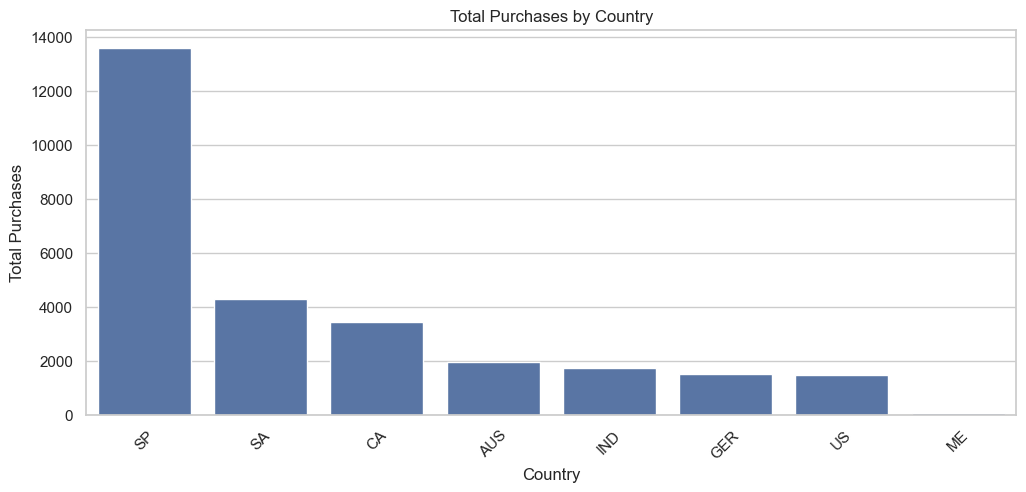

In [53]:
if {"Country", "TotalPurchases"}.issubset(df.columns):
    usa = df[df["Country"] == "USA"]["TotalPurchases"].dropna()
    non_usa = df[df["Country"] != "USA"]["TotalPurchases"].dropna()

    t_stat, p_val = stats.ttest_ind(usa, non_usa, equal_var=False)
    print("H4 – USA vs Rest of World: TotalPurchases")
    print("t-statistic:", t_stat, "p-value:", p_val)

    country_purchases = df.groupby("Country")["TotalPurchases"].sum().sort_values(ascending=False)
    display(country_purchases.head())

    plt.figure(figsize=(12, 5))
    sns.barplot(x=country_purchases.index, y=country_purchases.values)
    plt.xticks(rotation=45)
    plt.title("Total Purchases by Country")
    plt.ylabel("Total Purchases")
    plt.show()
else:
    print("Required columns for H4 not present.")


Product revenue:


MntWines            680816
MntMeatProducts     373968
MntGoldProds         98609
MntFishProducts      84057
MntSweetProducts     60621
MntFruits            58917
dtype: int64

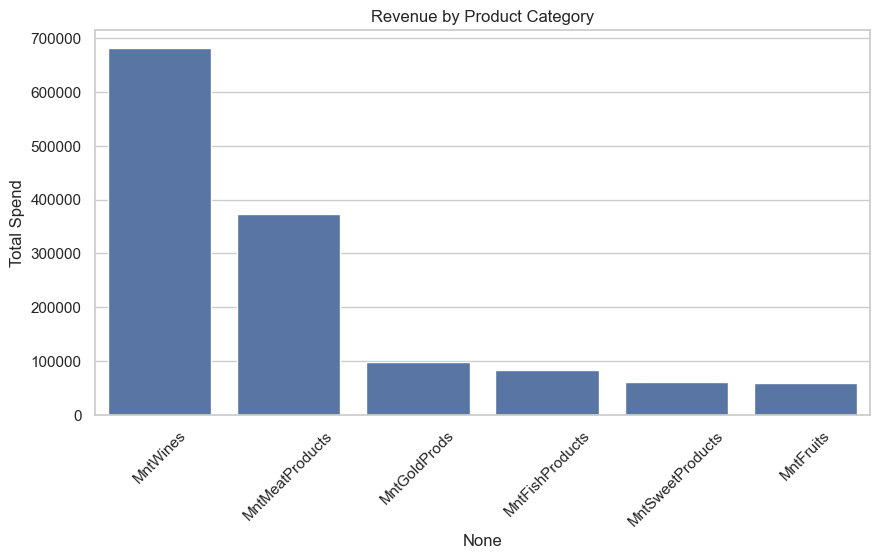

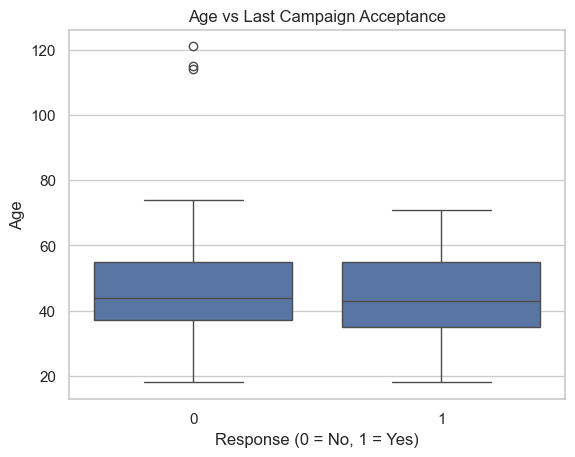

Correlation between Age and Response: -0.021325214441978192
Accepted customers by country:


Country
SP     176
SA      52
CA      38
AUS     23
GER     17
Name: Response, dtype: int64

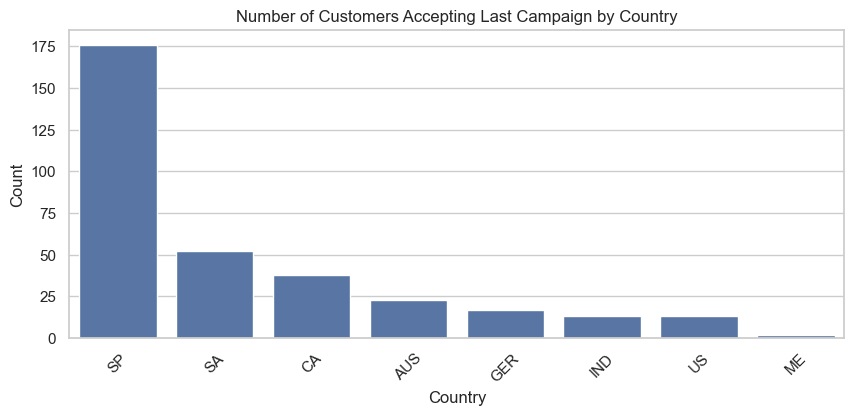

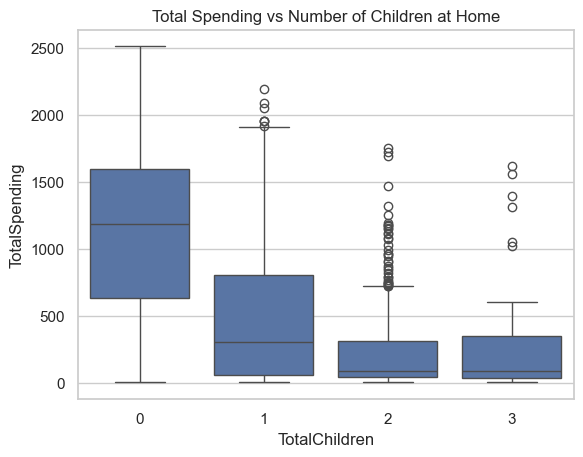

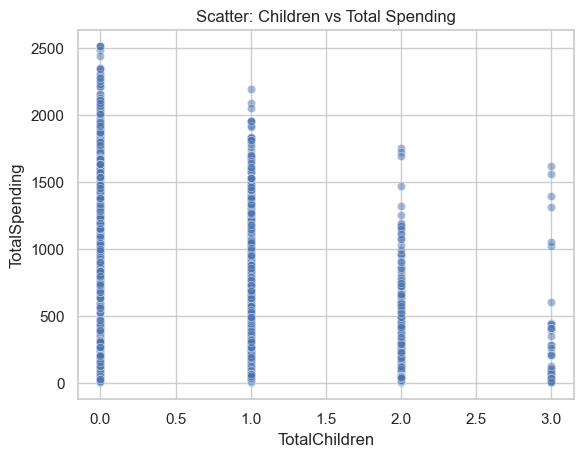

Complaints by Education level (last 2 years):


Education
Graduate        18
PostGraduate     3
Name: Complain, dtype: int64

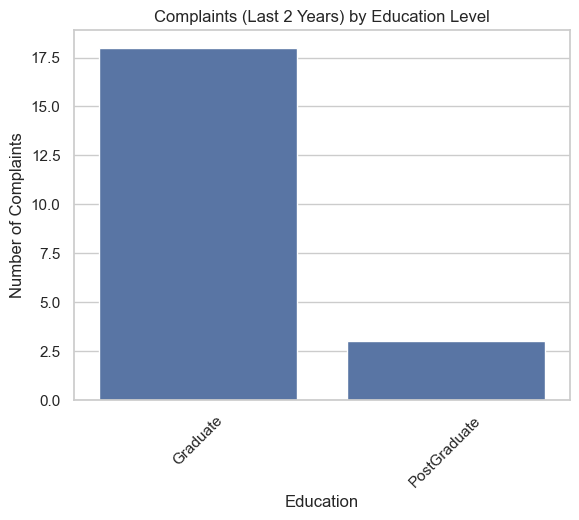

In [54]:
# 9.1 Top-performing & lowest revenue products (Mnt* columns)
product_cols = [c for c in df.columns if c.startswith("Mnt")]
if product_cols:
    product_revenue = df[product_cols].sum().sort_values(ascending=False)
    print("Product revenue:")
    display(product_revenue)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=product_revenue.index, y=product_revenue.values)
    plt.xticks(rotation=45)
    plt.title("Revenue by Product Category")
    plt.ylabel("Total Spend")
    plt.show()
else:
    print("No Mnt* product columns found.")

# 9.2 Age vs acceptance of last campaign (Response)
if {"Age", "Response"}.issubset(df.columns):
    plt.figure()
    sns.boxplot(x="Response", y="Age", data=df)
    plt.title("Age vs Last Campaign Acceptance")
    plt.xlabel("Response (0 = No, 1 = Yes)")
    plt.show()

    corr_age_resp = df["Age"].corr(df["Response"])
    print("Correlation between Age and Response:", corr_age_resp)
else:
    print("Columns Age/Response not available.")

# 9.3 Country with the highest number of customers who accepted last campaign
if {"Country", "Response"}.issubset(df.columns):
    accepted_by_country = df[df["Response"] == 1].groupby("Country")["Response"].count().sort_values(ascending=False)
    print("Accepted customers by country:")
    display(accepted_by_country.head())

    plt.figure(figsize=(10, 4))
    sns.barplot(x=accepted_by_country.index, y=accepted_by_country.values)
    plt.xticks(rotation=45)
    plt.title("Number of Customers Accepting Last Campaign by Country")
    plt.ylabel("Count")
    plt.show()
else:
    print("Columns Country/Response not available.")

# 9.4 Pattern between number of children and total expenditure
if {"TotalChildren", "TotalSpending"}.issubset(df.columns):
    plt.figure()
    sns.boxplot(x="TotalChildren", y="TotalSpending", data=df)
    plt.title("Total Spending vs Number of Children at Home")
    plt.show()

    plt.figure()
    sns.scatterplot(x="TotalChildren", y="TotalSpending", data=df, alpha=0.5)
    plt.title("Scatter: Children vs Total Spending")
    plt.show()
else:
    print("Columns TotalChildren/TotalSpending not available.")

# 9.5 Education of customers who complained in last 2 years
if {"Complain", "Education"}.issubset(df.columns):
    edu_complain = df[df["Complain"] == 1].groupby("Education")["Complain"].count().sort_values(ascending=False)
    print("Complaints by Education level (last 2 years):")
    display(edu_complain)

    plt.figure()
    sns.barplot(x=edu_complain.index, y=edu_complain.values)
    plt.xticks(rotation=45)
    plt.title("Complaints (Last 2 Years) by Education Level")
    plt.ylabel("Number of Complaints")
    plt.show()
else:
    print("Columns Complain/Education not available.")
